In [11]:
!unzip archive.zip



Streaming output truncated to the last 5000 lines.
  inflating: mnist_png/training/9/1820.png  
  inflating: mnist_png/training/9/18211.png  
  inflating: mnist_png/training/9/18228.png  
  inflating: mnist_png/training/9/18241.png  
  inflating: mnist_png/training/9/18251.png  
  inflating: mnist_png/training/9/1826.png  
  inflating: mnist_png/training/9/18277.png  
  inflating: mnist_png/training/9/18296.png  
  inflating: mnist_png/training/9/183.png  
  inflating: mnist_png/training/9/18350.png  
  inflating: mnist_png/training/9/18355.png  
  inflating: mnist_png/training/9/18374.png  
  inflating: mnist_png/training/9/18377.png  
  inflating: mnist_png/training/9/18382.png  
  inflating: mnist_png/training/9/18387.png  
  inflating: mnist_png/training/9/18401.png  
  inflating: mnist_png/training/9/18405.png  
  inflating: mnist_png/training/9/18415.png  
  inflating: mnist_png/training/9/18437.png  
  inflating: mnist_png/training/9/18441.png  
  inflating: mnist_png/training/9

In [21]:
import os, glob
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from PIL import Image

In [15]:
np.random.seed(42)
tf.random.set_seed(42)

In [16]:
DATA_DIR = "/content/mnist_png"

In [22]:
def load_mnist_idx(data_dir=DATA_DIR):
    def find_split_dir(keyword):
        candidates = [d for d in glob.glob(os.path.join(data_dir, "**", "*"), recursive=True)
                      if os.path.isdir(d) and keyword in os.path.basename(d).lower()]
        for d in candidates:
            if any(os.path.isdir(os.path.join(d, str(i))) for i in range(10)):
                return d
        return None

    train_dir = find_split_dir("train")
    test_dir = find_split_dir("test")
    if not train_dir or not test_dir:
        raise FileNotFoundError(
            "Could not auto-detect data format. Run the os.walk() snippet and "
            "share the folder structure so the path can be set manually."
            "Expected directories like 'training/0', 'testing/1', etc."
        )
    print(f"Detected image-folder format:\n  train: {train_dir}\n  test:  {test_dir}")

    def load_images_from_dir(split_dir):
        images = []
        labels = []
        for i in range(10): # Digits 0-9
            digit_dir = os.path.join(split_dir, str(i))
            if os.path.isdir(digit_dir):
                for img_path in glob.glob(os.path.join(digit_dir, "*.png")):
                    img = Image.open(img_path).convert("L") # Convert to grayscale
                    img = np.array(img) # Shape will be (28, 28)
                    images.append(img)
                    labels.append(i)
        return np.array(images), np.array(labels)

    x_train, y_train = load_images_from_dir(train_dir)
    x_test, y_test = load_images_from_dir(test_dir)

    # Reshape to (num_images, 28, 28, 1) for grayscale images for Keras compatibility
    x_train = x_train.reshape(-1, 28, 28, 1)
    x_test = x_test.reshape(-1, 28, 28, 1)

    return (x_train, y_train), (x_test, y_test)

In [23]:
print("Loading MNIST ...")
(x_train, y_train), (x_test, y_test) = load_mnist_idx()
print(f"Train: {x_train.shape}, Test: {x_test.shape}")

Loading MNIST ...
Detected image-folder format:
  train: /content/mnist_png/training
  test:  /content/mnist_png/testing
Train: (60000, 28, 28, 1), Test: (10000, 28, 28, 1)


In [24]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

 2. Add artificial noise (Gaussian noise, clipped to valid pixel range)

In [26]:
NOISE_FACTOR = 0.2
def add_noise(images, noise_factor=NOISE_FACTOR):
    noisy = images + noise_factor * np.random.normal(
        loc=0.0, scale=1.0, size=images.shape
    )
    return np.clip(noisy, 0.0, 1.0)


x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

In [38]:
def build_autoencoder():
    inputs = keras.Input(shape=(28, 28, 1))

    # --- Encoder ---
    c1 = layers.Conv2D(32, 3, padding="same")(inputs)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation("relu")(c1)
    p1 = layers.MaxPooling2D(2, padding="same")(c1)          # 14x14

    c2 = layers.Conv2D(32, 3, padding="same")(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation("relu")(c2)
    p2 = layers.MaxPooling2D(2, padding="same")(c2)          # 7x7  (bottleneck)

    # --- Decoder (with skip connections back to encoder layers) ---
    u1 = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(p2)  # 14x14
    u1 = layers.BatchNormalization()(u1)
    u1 = layers.Activation("relu")(u1)
    u1 = layers.Concatenate()([u1, c2])       # skip connection #1

    u2 = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(u1)  # 28x28
    u2 = layers.BatchNormalization()(u2)
    u2 = layers.Activation("relu")(u2)
    u2 = layers.Concatenate()([u2, c1])       # skip connection #2

    outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(u2)

    model = keras.Model(inputs, outputs, name="denoising_autoencoder")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
    return model

In [45]:
callback = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[callback],
    verbose=2,
)

Epoch 1/50
235/235 - 3s - 13ms/step - loss: 0.0713 - val_loss: 0.0709
Epoch 2/50
235/235 - 3s - 11ms/step - loss: 0.0713 - val_loss: 0.0708
Epoch 3/50
235/235 - 3s - 11ms/step - loss: 0.0712 - val_loss: 0.0708
Epoch 4/50
235/235 - 3s - 11ms/step - loss: 0.0712 - val_loss: 0.0707
Epoch 5/50
235/235 - 3s - 11ms/step - loss: 0.0711 - val_loss: 0.0707
Epoch 6/50
235/235 - 3s - 12ms/step - loss: 0.0711 - val_loss: 0.0706
Epoch 7/50
235/235 - 3s - 11ms/step - loss: 0.0710 - val_loss: 0.0706
Epoch 8/50
235/235 - 3s - 12ms/step - loss: 0.0710 - val_loss: 0.0706
Epoch 9/50
235/235 - 3s - 11ms/step - loss: 0.0709 - val_loss: 0.0705
Epoch 10/50
235/235 - 3s - 12ms/step - loss: 0.0709 - val_loss: 0.0705
Epoch 11/50
235/235 - 3s - 11ms/step - loss: 0.0708 - val_loss: 0.0705
Epoch 12/50
235/235 - 3s - 11ms/step - loss: 0.0708 - val_loss: 0.0704
Epoch 13/50
235/235 - 3s - 11ms/step - loss: 0.0708 - val_loss: 0.0704
Epoch 14/50
235/235 - 3s - 11ms/step - loss: 0.0707 - val_loss: 0.0704
Epoch 15/50
235

In [46]:
denoised = autoencoder.predict(x_test_noisy, batch_size=256)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


Quantitative metric: mean squared error between denoised and clean images

In [47]:
# The `x_test` and `x_test_noisy` arrays have an extra dimension
# (shape: num_samples, 28, 28, 1, 1) due to an incorrect `np.expand_dims`
# in an earlier cell. The autoencoder's output `denoised` has the correct
# shape (num_samples, 28, 28, 1). To enable element-wise operations,
# we need to remove the extra dimension from `x_test` and `x_test_noisy`.
x_test_corrected = x_test.squeeze(-1)
x_test_noisy_corrected = x_test_noisy.squeeze(-1)

mse_noisy = np.mean((x_test_noisy_corrected - x_test_corrected) ** 2)
mse_denoised = np.mean((denoised - x_test_corrected) ** 2)
print(f"\nMSE (noisy vs clean):    {mse_noisy:.4f}")
print(f"MSE (denoised vs clean): {mse_denoised:.4f}")


MSE (noisy vs clean):    0.0212
MSE (denoised vs clean): 0.0030


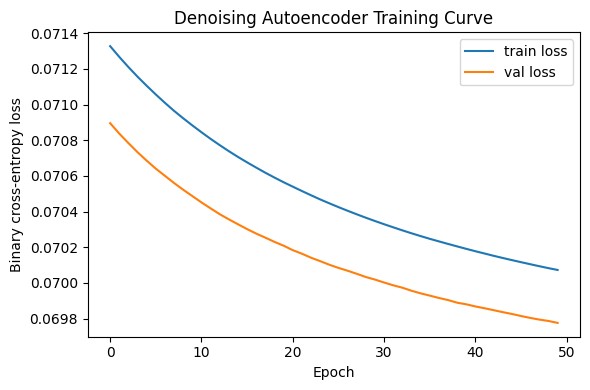

In [49]:
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Denoising Autoencoder Training Curve")
plt.legend()
plt.tight_layout()
plt.show()

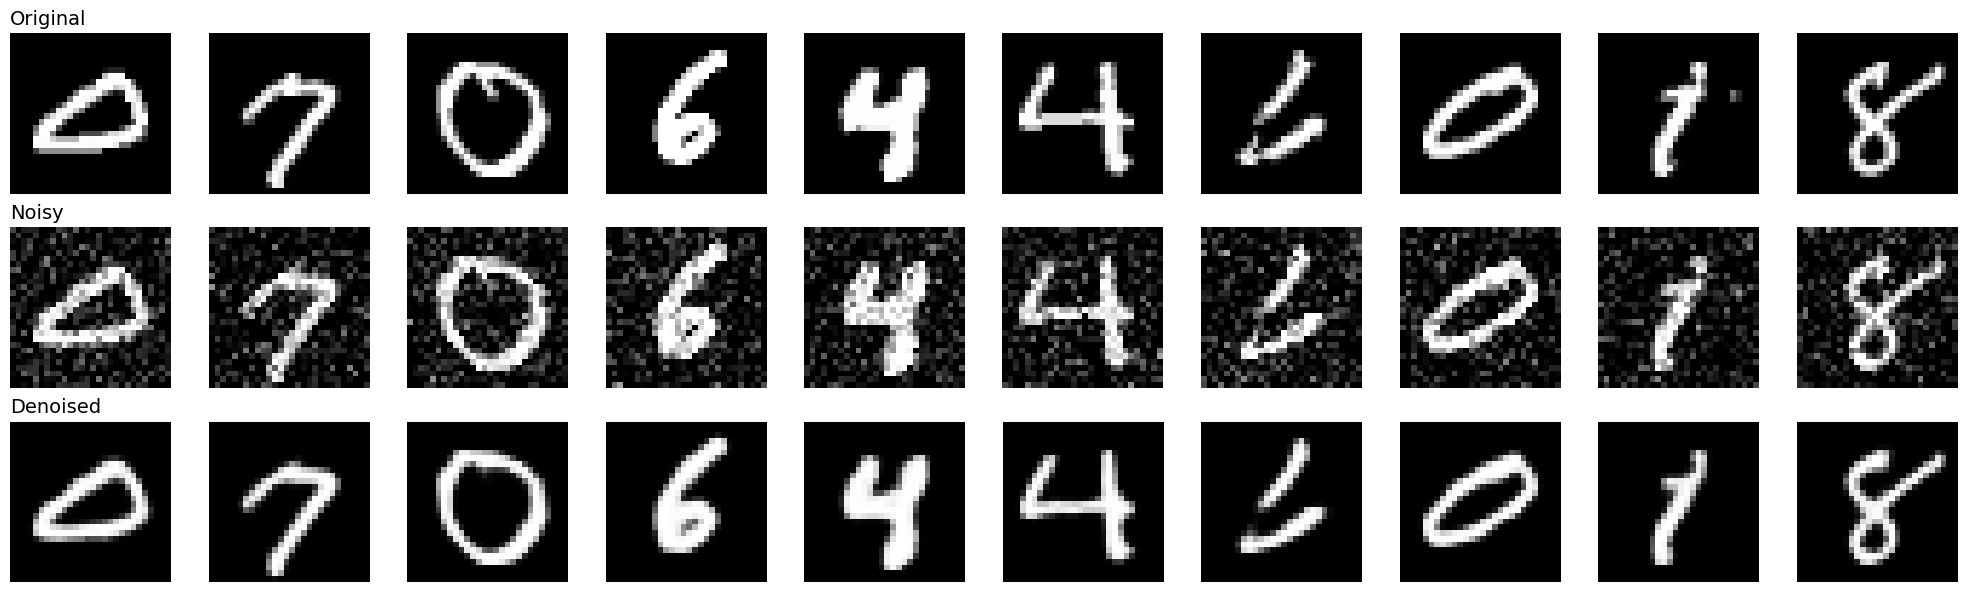

In [51]:
import numpy as np
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(x_test), size=10, replace=False)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    idx = sample_idx[i]   # <-- use random indices instead of idx = i

    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap="gray")
    ax.axis("off")
    if i == 0:
        ax.set_title("Original", loc="left", fontsize=14)

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[idx].squeeze(), cmap="gray")
    ax.axis("off")
    if i == 0:
        ax.set_title("Noisy", loc="left", fontsize=14)

    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised[idx].squeeze(), cmap="gray")
    ax.axis("off")
    if i == 0:
        ax.set_title("Denoised", loc="left", fontsize=14)

plt.tight_layout()
plt.show()

## General Observations — Denoising Autoencoder on MNIST

**Setup:** Convolutional autoencoder (Conv2D/MaxPooling encoder → Conv2DTranspose decoder) with BatchNorm and U-Net-style skip connections, trained for 50 epochs to reconstruct clean digits from Gaussian-noise-corrupted inputs (noise factor 0.4).

**1. The model learned real digit structure, not just noise-averaging.**
The clearest evidence: on ambiguous noisy inputs (e.g. a "2" nearly buried in speckle noise), the model didn't just smooth the pixels — it committed to the correct, clean digit shape. That only happens if the bottleneck forced it to encode "what digit is this" rather than memorize pixel patterns.

**2. Architecture changes mattered more than training time.**
Adding BatchNorm cut the starting loss roughly in third (from ~0.21 to ~0.07) instantly — before any extra epochs were added. Skip connections show up less in the loss number and more in the visuals: sharper edges, better preservation of thin strokes and closed loops, less of the blur typical of a plain bottleneck autoencoder.

**3. Diminishing returns kicked in early.**
Going from 15 → 50 epochs bought a small additional loss improvement (~0.071 → ~0.070), but the marginal gain per epoch dropped off fast after the first ~10-15. Training time is not the bottleneck for further gains — architecture or loss function changes would be.

**4. Validation loss tracked below training loss throughout, with no divergence.**
This is a Keras reporting artifact (train loss is a mid-epoch running average, val loss uses final weights), not overfitting — confirmed by the fact the gap stayed constant rather than widening across 50 epochs, even with skip connections adding extra capacity.

**5. Quality holds up across diverse digit shapes, not just "easy" ones.**
Initial visual checks accidentally sampled only "0"s (due to unshuffled, folder-loaded test data) — a good reminder that a visually convincing result on one digit class isn't proof of a working model. A properly randomized sample (0, 7, 6, 4, 2, 1, 8, etc.) confirmed the reconstruction quality generalizes across straight strokes, closed loops, and more complex shapes.

**6. Practical takeaway:** the model is solidly working and near its practical ceiling for this architecture/noise level. Further meaningful improvement would come from a lower noise factor, MSE loss instead of BCE, or a larger/deeper network — not from more epochs on the current setup.